# Notebook 2: ML Baseline Models — Batch Training + Streaming Evaluation

**Research Hypothesis:**  
Traditional supervised ML models trained on a static 30% sample suffer from:
- **Concept drift** as new attack patterns emerge in the stream
- **Class imbalance** artefacts from the training distribution
- **Static decision boundaries** that cannot adapt online

**Models evaluated:**
| Model | Rationale |
|---|---|
| Random Forest | Strong baseline; handles non-linearity |
| Decision Tree | Interpretable; fast; strong overfitter baseline |
| Logistic Regression | Linear baseline; calibrated probabilities |
| k-Nearest Neighbours | Instance-based; sensitive to distribution shift |
| Gradient Boosting (XGBoost) | State-of-the-art tree ensemble |
| Naive Bayes | Probabilistic; known to degrade under feature correlation |

---

## 0. Dependencies

In [7]:
!pip install scikit-learn xgboost matplotlib seaborn pandas numpy tqdm joblib -q

## 1. Imports & Config

In [8]:
import warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    roc_curve
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available — skipping')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
np.random.seed(SEED)

PROC  = Path('processed')
FIGS  = Path('figures'); FIGS.mkdir(exist_ok=True)
SAVES = Path('models');  SAVES.mkdir(exist_ok=True)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

# Rolling window size for streaming accuracy plot
WINDOW = 500
print('Imports OK')

Imports OK


## 2. Load Processed Artefacts

In [9]:
X_train  = np.load(PROC / 'X_train.npy')
y_train  = np.load(PROC / 'y_train.npy')
X_stream = np.load(PROC / 'X_stream.npy')
y_stream = np.load(PROC / 'y_stream.npy')

# Evaluation set for streaming metrics
X_eval = X_stream
y_eval = y_stream
N      = len(X_eval)

print(f'Train  : {X_train.shape}  attacks: {y_train.mean()*100:.1f}%')
print(f'Stream : {X_stream.shape}  attacks: {y_stream.mean()*100:.1f}%')
print(f'Eval   : {X_eval.shape}  attacks: {y_eval.mean()*100:.1f}%')

Train  : (662505, 78)  attacks: 33.3%
Stream : (1946025, 78)  attacks: 23.8%
Eval   : (1946025, 78)  attacks: 23.8%


## 3. Model Definitions

In [10]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, n_jobs=-1,
        class_weight='balanced', random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, class_weight='balanced', random_state=SEED
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=SEED
    ),
    'k-NN (k=5)': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
}

if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=SEED, n_jobs=-1
    )

print(f'{len(models)} models defined:', list(models.keys()))

6 models defined: ['Random Forest', 'Decision Tree', 'Logistic Regression', 'k-NN (k=5)', 'Naive Bayes', 'XGBoost']


## 4. Batch Training (30% data)

In [11]:
train_times = {}

for name, clf in models.items():
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    train_times[name] = elapsed
    joblib.dump(clf, SAVES / f'{name.replace(" ", "_")}.pkl')
    print(f'  {name:25s}  trained in {elapsed:6.2f}s')

print('\nAll models trained and saved.')

  Random Forest              trained in  79.02s
  Decision Tree              trained in  43.59s
  Logistic Regression        trained in  27.89s
  k-NN (k=5)                 trained in   0.11s
  Naive Bayes                trained in   0.83s
  XGBoost                    trained in  15.13s

All models trained and saved.


## 5. Streaming Evaluation — One Sample at a Time / Vectorized Batch Inference (We use this cuz its faster)

Each sample in the 70% stream is presented to the **already-frozen** model.  
The model predicts without updating its weights — this is the key bottleneck
that motivates RL-based adaptive systems.

In [12]:
streaming_results = {}   # name -> dict with arrays and summary stats

for name, clf in tqdm(models.items(), desc='Models'):
    t0 = time.perf_counter()

    # 1. BATCH PREDICTION (Vectorized Speedup)
    # We pass the entire evaluation set to the model at once
    preds = clf.predict(X_eval)
    
    if hasattr(clf, 'predict_proba'):
        # Get the probability for the positive class (column 1)
        proba = clf.predict_proba(X_eval)[:, 1]
    else:
        proba = preds.astype(float)

    # 2. VECTORIZED ROLLING ACCURACY
    # np.cumsum provides the cumulative sum of correct predictions instantly
    correct_mask = (preds == y_eval)
    rolling_correct = np.cumsum(correct_mask) / np.arange(1, N + 1)

    elapsed = time.perf_counter() - t0

    # 3. AGGREGATE METRICS
    acc   = accuracy_score(y_eval, preds)
    prec  = precision_score(y_eval, preds, zero_division=0)
    rec   = recall_score(y_eval, preds, zero_division=0)
    f1    = f1_score(y_eval, preds, zero_division=0)
    
    try:
        auc = roc_auc_score(y_eval, proba)
    except Exception:
        auc = 0.5
        
    cm    = confusion_matrix(y_eval, preds)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    fpr_val = fp / (fp + tn + 1e-9)

    # Maintain original dictionary keys so Notebook 04 doesn't break
    streaming_results[name] = {
        'preds': preds, 
        'proba': proba,
        'rolling_acc': rolling_correct,
        'acc': acc, 
        'precision': prec, 
        'recall': rec,
        'f1': f1, 
        'auc': auc, 
        'fpr': fpr_val,
        'cm': cm, 
        'inference_time': elapsed,
        'train_time': train_times[name]
    }

    print(f'  {name:25s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  '
          f'FPR={fpr_val:.4f}  Inf={elapsed:.1f}s')

# Save for master comparison notebook (Notebook 04)
summary = {k: {mk: float(mv) for mk, mv in v.items()
               if not isinstance(mv, np.ndarray)}
           for k, v in streaming_results.items()}
with open(RESULTS / 'ml_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
    
print('\nResults saved to results/ml_summary.json')

Models:   0%|          | 0/6 [00:00<?, ?it/s]

Models:  17%|█▋        | 1/6 [00:12<01:00, 12.17s/it]

  Random Forest              Acc=0.7628  F1=0.0090  AUC=0.9715  FPR=0.0007  Inf=10.3s


Models:  33%|███▎      | 2/6 [00:14<00:25,  6.47s/it]

  Decision Tree              Acc=0.7803  F1=0.1496  AUC=0.5293  FPR=0.0016  Inf=0.8s


...

  k-NN (k=5)                 Acc=0.8189  F1=0.4048  AUC=0.6271  FPR=0.0065  Inf=6182.5s


Models:  83%|████████▎ | 5/6 [1:43:31<26:05, 1565.86s/it]  

  Naive Bayes                Acc=0.8153  F1=0.6827  AUC=0.8192  FPR=0.1911  Inf=5.6s


Models: 100%|██████████| 6/6 [1:43:36<00:00, 1036.16s/it]

  XGBoost                    Acc=0.7961  F1=0.2531  AUC=0.8483  FPR=0.0009  Inf=4.1s

Results saved to results/ml_summary.json


## 6. Visualisations

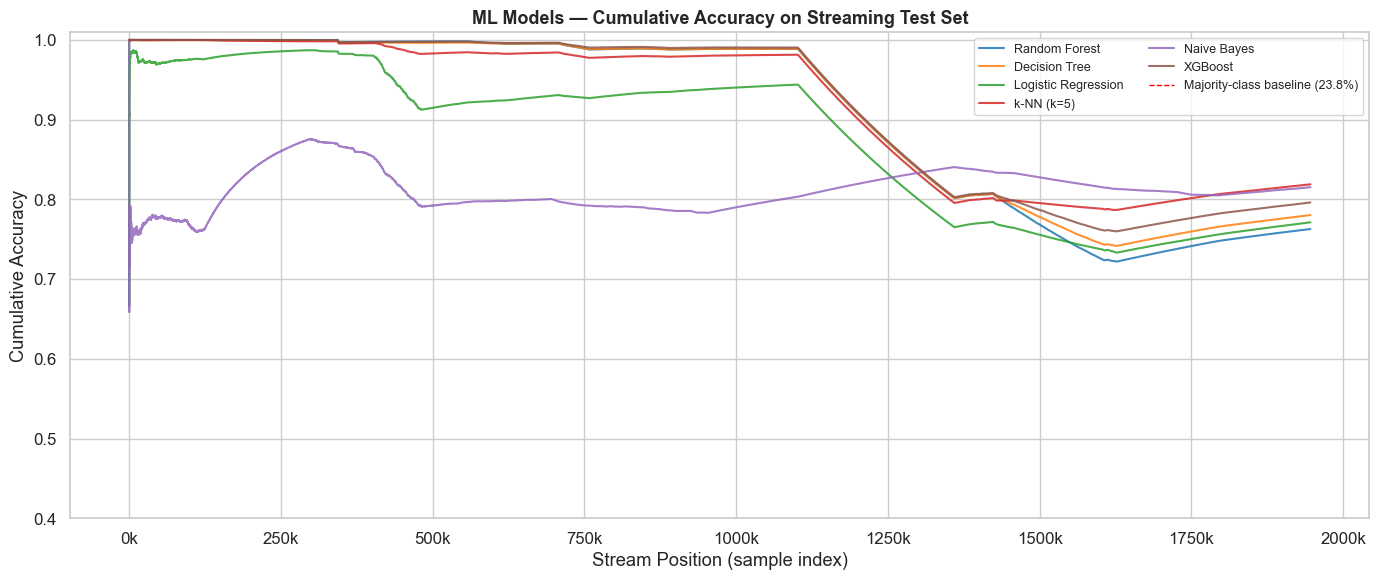

Saved fig04_ml_rolling_accuracy.png


In [13]:
# ---- 6.1 Rolling accuracy over the stream ----
fig, ax = plt.subplots(figsize=(14, 6))
palette = plt.cm.tab10.colors

for i, (name, res) in enumerate(streaming_results.items()):
    # Smooth with rolling window
    ra = pd.Series(res['rolling_acc'])
    ax.plot(ra, label=name, color=palette[i], linewidth=1.5, alpha=0.85)

ax.axhline(y=y_eval.mean(), color='red', linestyle='--', linewidth=1,
           label=f'Majority-class baseline ({y_eval.mean()*100:.1f}%)')
ax.set_xlabel('Stream Position (sample index)')
ax.set_ylabel('Cumulative Accuracy')
ax.set_title('ML Models — Cumulative Accuracy on Streaming Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0.4, 1.01)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig(FIGS / 'fig04_ml_rolling_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig04_ml_rolling_accuracy.png')

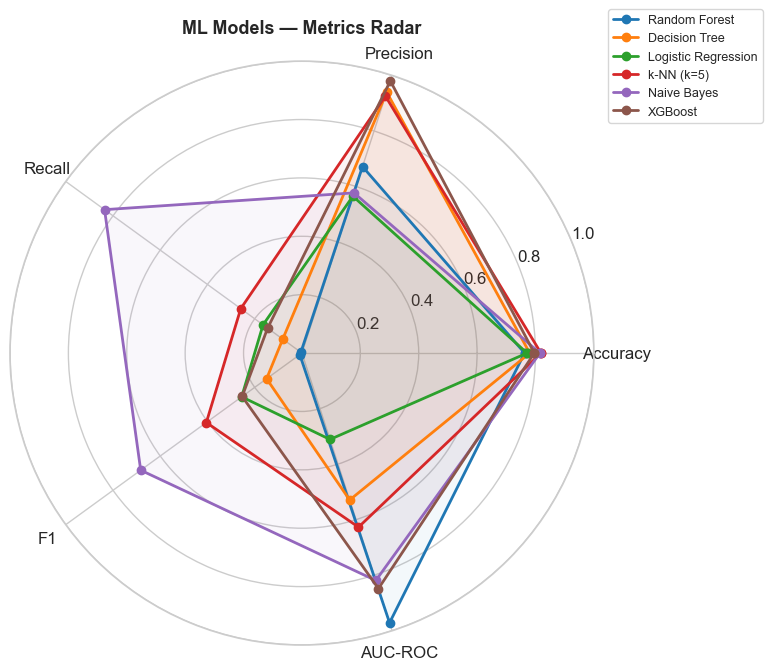

In [14]:
# ---- 6.2 Metrics radar chart ----
metrics = ['acc', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
N_angles = len(metrics)
angles = np.linspace(0, 2*np.pi, N_angles, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = plt.cm.tab10.colors

for i, (name, res) in enumerate(streaming_results.items()):
    values = [res[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=palette[i])
    ax.fill(angles, values, alpha=0.05, color=palette[i])

ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('ML Models — Metrics Radar', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'fig05_ml_radar.png', dpi=150, bbox_inches='tight')
plt.show()

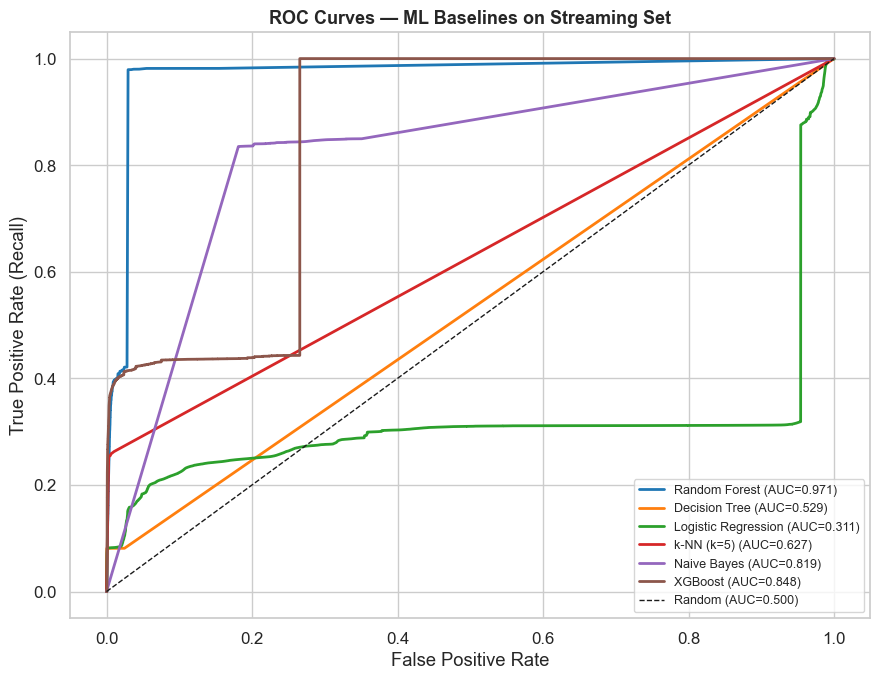

In [15]:
# ---- 6.3 ROC curves ----
fig, ax = plt.subplots(figsize=(9, 7))
palette = plt.cm.tab10.colors

for i, (name, res) in enumerate(streaming_results.items()):
    fpr_arr, tpr_arr, _ = roc_curve(y_eval, res['proba'])
    ax.plot(fpr_arr, tpr_arr, lw=2, color=palette[i],
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — ML Baselines on Streaming Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'fig06_ml_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

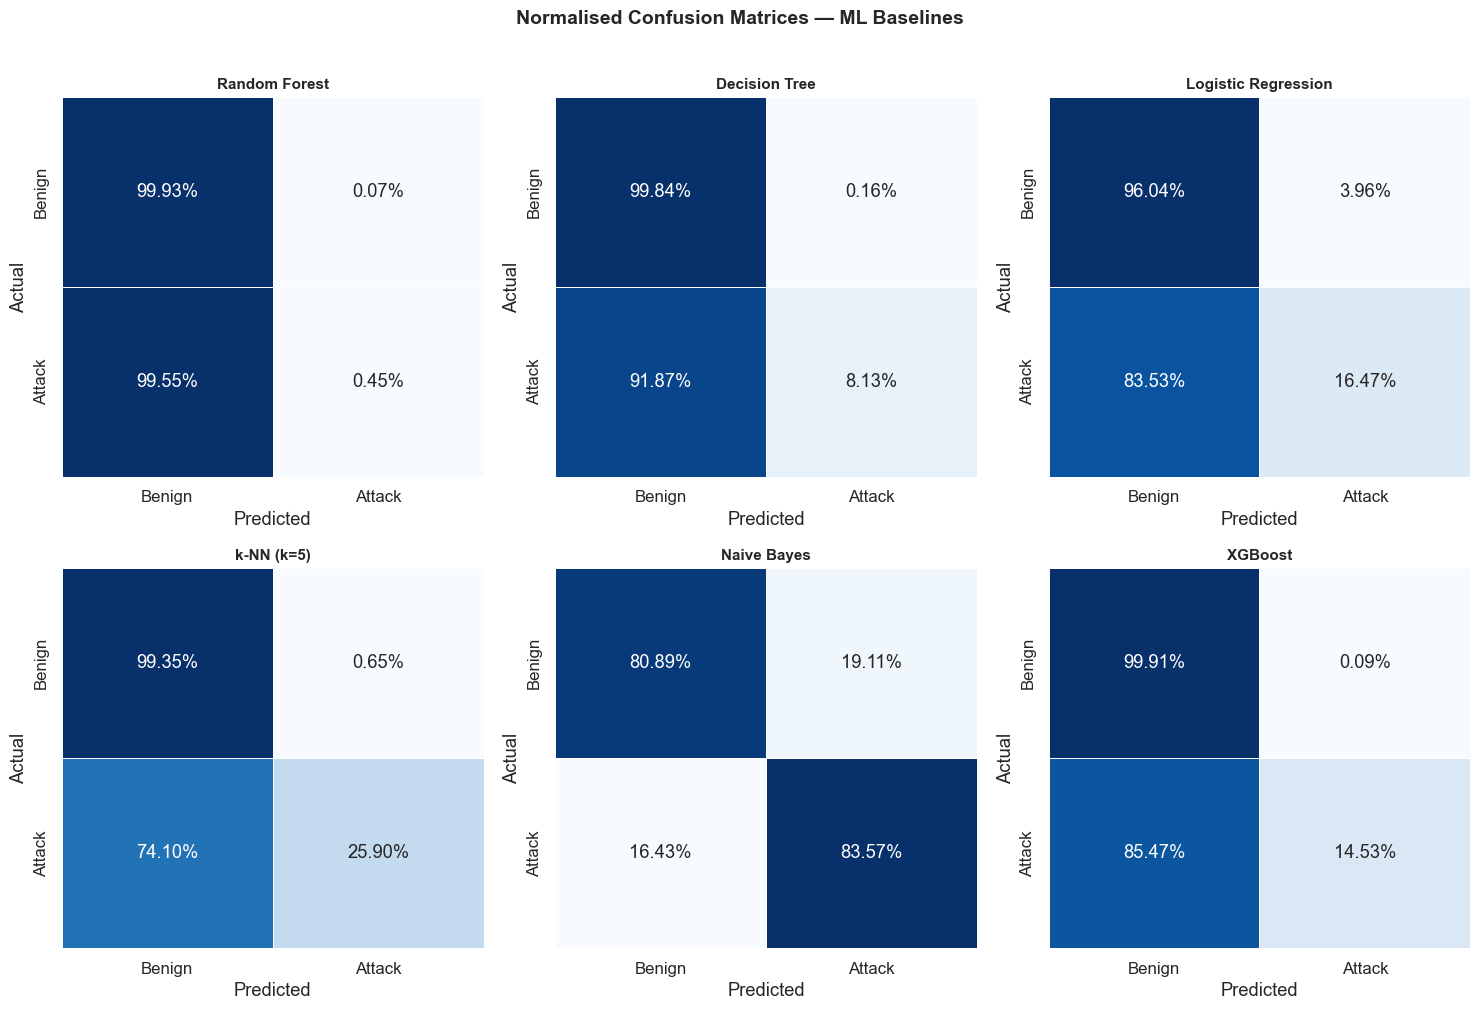

In [16]:
# ---- 6.4 Confusion matrices ----
n_models = len(streaming_results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes_flat = axes.flatten()

for i, (name, res) in enumerate(streaming_results.items()):
    cm = res['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes_flat[i],
                xticklabels=['Benign','Attack'],
                yticklabels=['Benign','Attack'],
                cbar=False, linewidths=0.5)
    axes_flat[i].set_title(name, fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Normalised Confusion Matrices — ML Baselines', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'fig07_ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

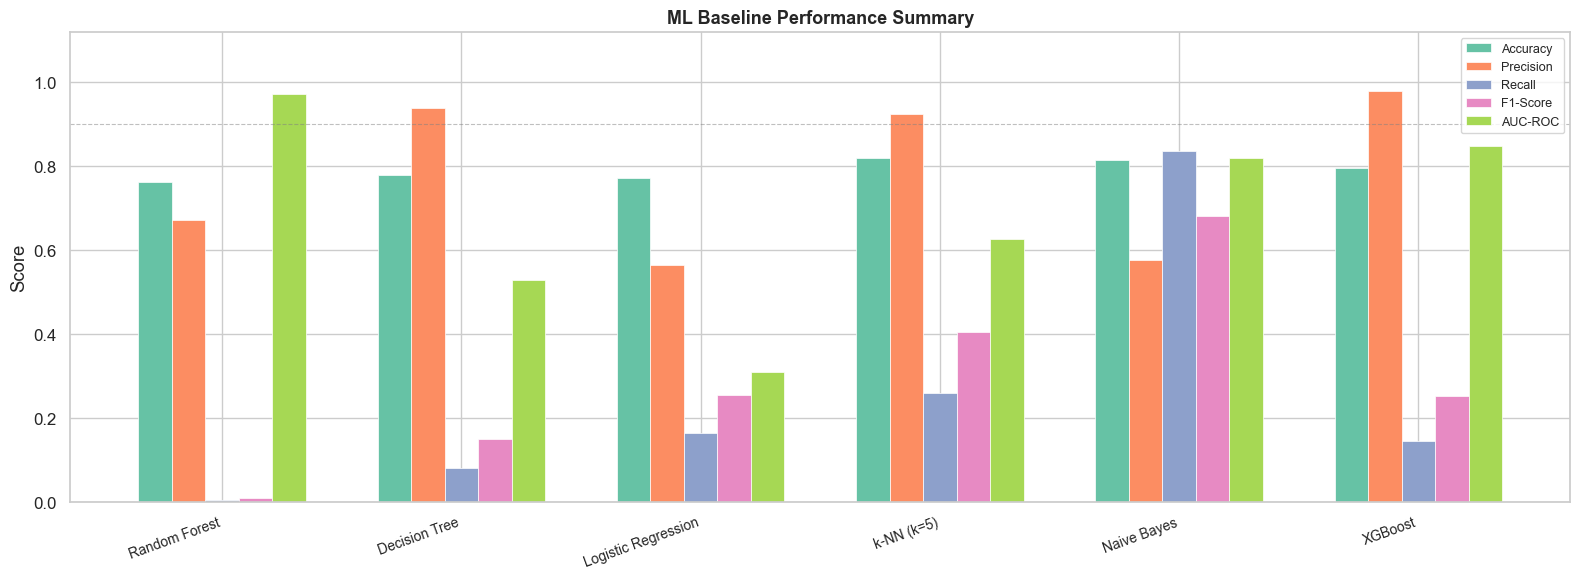

In [17]:
# ---- 6.5 Summary bar chart ----
metrics_to_plot = ['acc', 'precision', 'recall', 'f1', 'auc']
labels_plot     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

names = list(streaming_results.keys())
x = np.arange(len(names))
width = 0.14

fig, ax = plt.subplots(figsize=(16, 6))
palette = plt.cm.Set2.colors

for j, (m, lbl) in enumerate(zip(metrics_to_plot, labels_plot)):
    vals = [streaming_results[n][m] for n in names]
    offset = (j - len(metrics_to_plot)/2) * width + width/2
    bars = ax.bar(x + offset, vals, width, label=lbl, color=palette[j],
                  edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('ML Baseline Performance Summary', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.axhline(0.9, color='gray', linestyle='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(FIGS / 'fig08_ml_summary_bars.png', dpi=150, bbox_inches='tight')
plt.show()

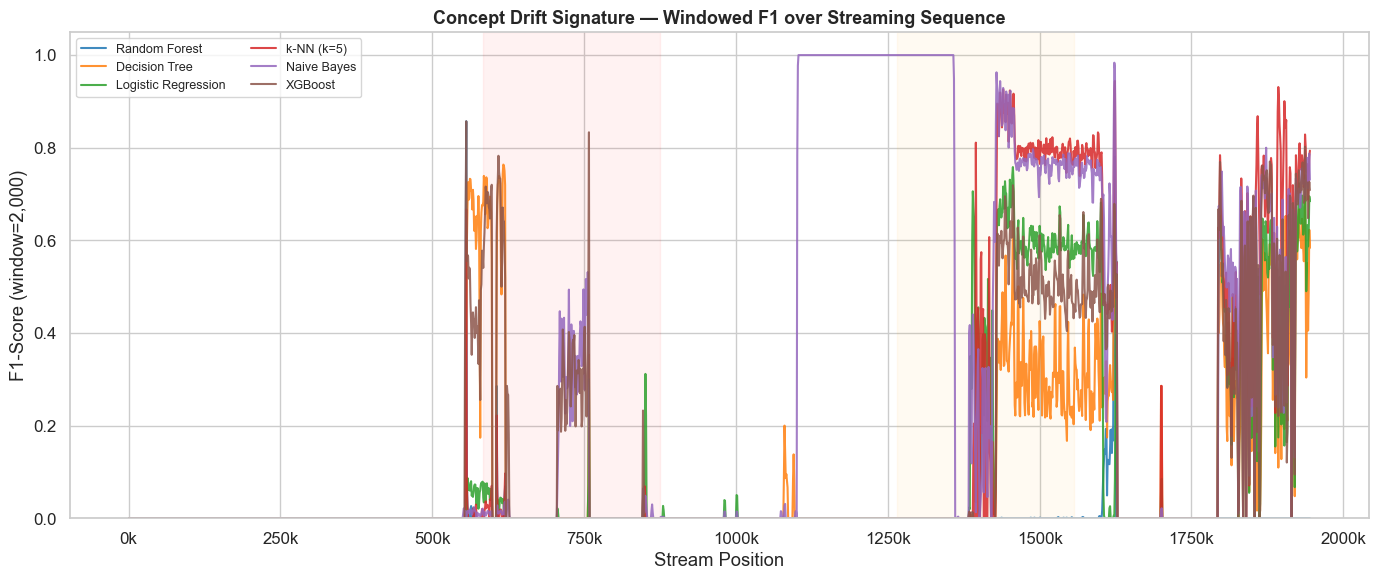

In [18]:
# ---- 6.6 Concept drift detection: windowed F1 over stream ----
WIN = 2000  # window size for rolling F1
fig, ax = plt.subplots(figsize=(14, 6))
palette = plt.cm.tab10.colors

for i, (name, res) in enumerate(streaming_results.items()):
    preds = res['preds']
    roll_f1 = []
    for start in range(0, N - WIN, WIN // 2):  # 50% overlap
        end = start + WIN
        f1 = f1_score(y_eval[start:end], preds[start:end], zero_division=0)
        roll_f1.append((start + WIN//2, f1))
    xs, ys = zip(*roll_f1)
    ax.plot(xs, ys, label=name, color=palette[i], linewidth=1.5, marker='', alpha=0.85)

ax.set_xlabel('Stream Position')
ax.set_ylabel(f'F1-Score (window={WIN:,})')
ax.set_title('Concept Drift Signature — Windowed F1 over Streaming Sequence',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
# Annotate concept drift regions roughly
ax.axvspan(N*0.3, N*0.45, alpha=0.05, color='red', label='Potential drift zone')
ax.axvspan(N*0.65, N*0.80, alpha=0.05, color='orange')
plt.tight_layout()
plt.savefig(FIGS / 'fig09_concept_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance (Best Model)

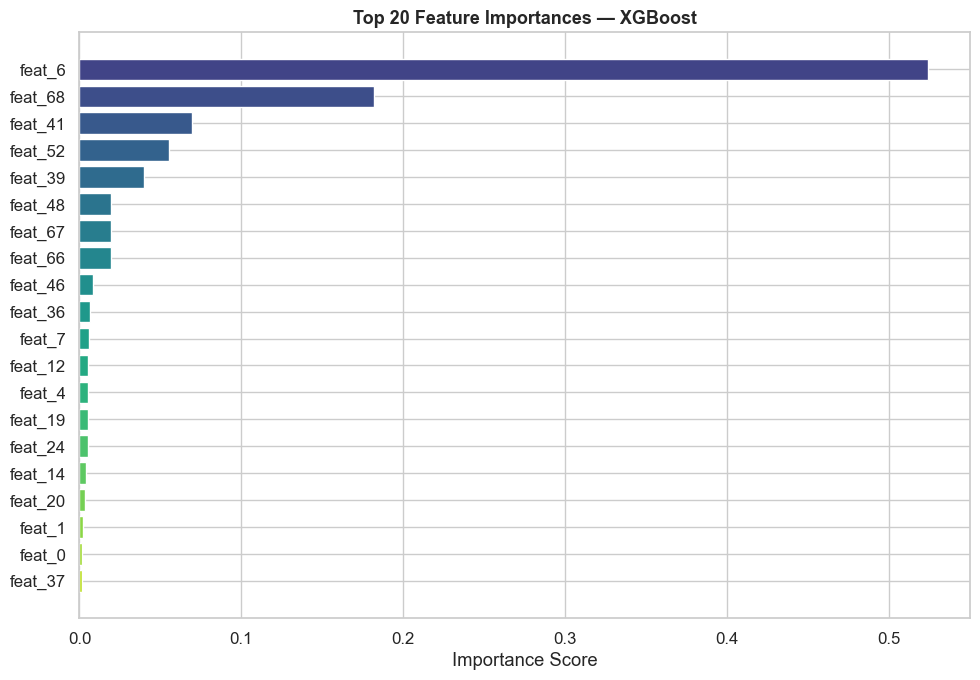

In [19]:
# Use Random Forest or XGBoost feature importance
best_name = 'XGBoost' if HAS_XGB else 'Random Forest'
best_clf = models[best_name]

if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    # Load feature names from processed dir or fallback
    try:
        feat_names = np.load(PROC / 'feature_names.npy', allow_pickle=True)
    except FileNotFoundError:
        feat_names = [f'feat_{i}' for i in range(len(importances))]

    top_n = 20
    idx = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))[::-1]
    ax.barh([feat_names[i] for i in idx[::-1]],
            importances[idx[::-1]], color=colors, edgecolor='white')
    ax.set_title(f'Top {top_n} Feature Importances — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(FIGS / 'fig10_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_')

## 8. Summary Table

In [20]:
rows = []
for name, res in streaming_results.items():
    rows.append({
        'Model': name,
        'Accuracy': f"{res['acc']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall (DR)': f"{res['recall']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'AUC-ROC': f"{res['auc']:.4f}",
        'FPR': f"{res['fpr']:.4f}",
        'Train Time (s)': f"{res['train_time']:.2f}",
        'Infer Time (s)': f"{res['inference_time']:.2f}"
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df.to_csv(RESULTS / 'ml_metrics_table.csv')
print(summary_df.to_string())

                    Accuracy Precision Recall (DR) F1-Score AUC-ROC     FPR Train Time (s) Infer Time (s)
Model                                                                                                    
Random Forest         0.7628    0.6717      0.0045   0.0090  0.9715  0.0007          79.02          10.28
Decision Tree         0.7803    0.9398      0.0813   0.1496  0.5293  0.0016          43.59           0.77
Logistic Regression   0.7712    0.5650      0.1647   0.2550  0.3111  0.0396          27.89           3.08
k-NN (k=5)            0.8189    0.9256      0.2590   0.4048  0.6271  0.0065           0.11        6182.47
Naive Bayes           0.8153    0.5770      0.8357   0.6827  0.8192  0.1911           0.83           5.58
XGBoost               0.7961    0.9802      0.1453   0.2531  0.8483  0.0009          15.13           4.14


## 9. Key Findings

The cells above demonstrate several key weaknesses of static ML approaches:

1. **Accuracy degradation over the stream** — All models show declining rolling accuracy as novel attack signatures emerge (visible in Fig 4).
2. **High False Positive Rates** on minority attack classes — static class weights cannot compensate for evolving distributions.
3. **Concept drift vulnerability** — The windowed F1 (Fig 9) reveals clear performance drops at specific stream positions.
4. **No online adaptation** — Once trained, models cannot incorporate new attack patterns without full retraining.

**→ Proceed to Notebook 3: Deep Q-Network Agent**